In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ttest_rel, pearsonr
from upsetplot import UpSet, from_memberships

    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from scipy.stats import pearsonr
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes


        import os
    import re
    import pandas as pd
    import matplotlib.pyplot as plt
    from venn import venn
    from matplotlib.colors import ListedColormap


## SINGLE

### Figure 1

In [ ]:
def singlerna_permetric(input_dir, output_dir):
    # define labels for all methods
    custom_labels = {
        'af3': 'AF3',
        'chai': 'Chai',
        'hf3': 'HF3',
        'rf2na': 'RF2NA',
        'boltz': 'Boltz-1',
        'rhofold': 'RhoFold+',
        'nufold': 'NuFold',
        'trrosetta': 'trRosettaRNA'
    }

    os.makedirs(output_dir, exist_ok=True)

    # make sure that we plot only common IDs
    dfs = []
    csv_files = [f for f in os.listdir(input_dir) if f.endswith('-single.csv')]
    common_ids = None

    for file in csv_files:
        file_path = os.path.join(input_dir, file)
        df = pd.read_csv(file_path)

        cols_present = set(df.columns)
        must_have = {'PDB_ID', 'TM-scoreRNA', 'INF-ALL', 'lddt'}
        missing_must = must_have - cols_present
        if missing_must:
            print(f"[WARN] Skipping {file}: missing columns {missing_must}")
            continue

        base = file.replace('-single.csv', '')  # e.g., 'af3'
        model_name = custom_labels.get(base, base)

        keep_cols = ['PDB_ID', 'TM-scoreRNA', 'INF-ALL', 'lddt']
        if 'GDT-TS' in df.columns:
            keep_cols.append('GDT-TS')
        sub = df[keep_cols].drop_duplicates()
        if 'GDT-TS' not in sub.columns:
            sub['GDT-TS'] = pd.NA # in case of some inconsistencies

        dfs.append((model_name, sub))

        ids_here = set(sub['PDB_ID'].astype(str).str.strip().str.upper())
        if common_ids is None:
            common_ids = ids_here
        else:
            common_ids &= ids_here

    if not dfs or not common_ids:
        raise RuntimeError("No comparable data found after intersecting PDB_IDs across methods.")

    # build a dataframe
    long_rows = []
    for model_name, sub in dfs:
        sub = sub.copy()
        sub['PDB_ID_norm'] = sub['PDB_ID'].astype(str).str.strip().str.upper()
        sub = sub[sub['PDB_ID_norm'].isin(common_ids)]

        sub_long = pd.DataFrame({
            'PDB_ID': sub['PDB_ID'].values,
            'Model': model_name,
            'TM-scoreRNA': sub['TM-scoreRNA'].values,
            'INF': sub['INF-ALL'].values,
            'lddt': sub['lddt'].values,
            'GDT-TS': sub['GDT-TS'].values
        })

        for score_col in ['TM-scoreRNA', 'INF', 'lddt', 'GDT-TS']:
            vals = pd.to_numeric(sub_long[score_col], errors='coerce')
            mask = vals.notna()
            if mask.any():
                long_rows.append(pd.DataFrame({
                    'Model': model_name,
                    'ScoreType': score_col,
                    'Value': vals[mask].values
                }))

    combined_df = pd.concat(long_rows, ignore_index=True)

    order_series = (
        combined_df[combined_df['ScoreType'] == 'TM-scoreRNA']
        .groupby('Model')['Value']
        .mean()
        .sort_values(ascending=False)
    )
    model_order = order_series.index.tolist()

    # plot
    score_types = ['TM-scoreRNA', 'INF', 'lddt', 'GDT-TS']
    pretty_names = {
        'TM-scoreRNA': 'TM-score',
        'INF': 'INF-ALL',
        'lddt': 'lDDT',
        'GDT-TS': 'GDT-TS'
    }

    n_models = len(model_order)
    n_metrics = len(score_types)

    # spacing
    box_width = 0.8
    group_spacing = 0.8
    left_padding = 0.3


    # overal width 
    fig_width = max(10, 0.7 * n_models * n_metrics)
    fig, ax = plt.subplots(figsize=(fig_width, 5))

    # color per method
    base_cmap = plt.get_cmap('tab20')
    model_colors = {
        model: base_cmap(i % 20)
        for i, model in enumerate(model_order)
    }

    legend_handles = {}
    x_ticks = []
    x_labels = []

    for m_idx, st in enumerate(score_types):

        group_start = m_idx * (n_models + group_spacing) + left_padding * m_idx

        for i, model in enumerate(model_order):
            scores = combined_df[
                (combined_df['Model'] == model) &
                (combined_df['ScoreType'] == st)
            ]['Value'].dropna()

            if scores.empty:
                continue

            pos = group_start + i
            color = model_colors[model]

            bplot = ax.boxplot(
                scores,
                positions=[pos],
                widths=box_width,
                patch_artist=True,
                boxprops=dict(facecolor=color, edgecolor='black', linewidth=1),
                medianprops=dict(color='black'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'),
                flierprops=dict(marker='o', markersize=3, linestyle='none',
                                markerfacecolor=color)
            )

            if model not in legend_handles:
                legend_handles[model] = bplot["boxes"][0]

        center = group_start + (n_models - 1) / 2
        x_ticks.append(center)
        x_labels.append(pretty_names[st])

    # axis
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=16, fontweight='bold')
    ax.set_ylabel("Score", fontsize=16)
    ax.set_title("Performance on Single RNA", fontsize=20)
    ax.set_ylim(0, 1)

    for m_idx in range(1, n_metrics):
        boundary = m_idx * (n_models + group_spacing)
        ax.axvline(boundary - 0.25, color='grey', linestyle='--', linewidth=0.4, alpha=0.4)

    # add legend
    ax.legend(
        [legend_handles[m] for m in model_order if m in legend_handles],
        [m for m in model_order if m in legend_handles],
        title="Method",
        bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0
    )

    plt.tight_layout()
    fig_path = os.path.join(output_dir, "Fig-1A.png")
    fig.savefig(fig_path, dpi=300)
    plt.close(fig)
    print(f"Saved figure to {fig_path}")


In [5]:
singlerna_permetric(
    input_dir="../OUTPUTS/single",
    output_dir="../OUTPUTS/figures"
)

Saved figure to ../OUTPUTS/figures/Fig-1A_metrics.png


In [7]:
def compare_to_af3(
    input_dir,
    output_dir
):
    """
    Compare models to AF3, the top-performing model for TM-score
    """
 
    os.makedirs(output_dir, exist_ok=True)

    custom_labels = {
        'af3': 'AF3',
        'chai': 'Chai',
        'hf3': 'HF3',
        'rf2na': 'RF2NA',
        'boltz': 'Boltz-1',
        'rhofold': 'RhoFold+',
        'nufold': 'NuFold',
        'trrosetta': 'trRosettaRNA'
    }

    csv_files = [f for f in os.listdir(input_dir) if f.endswith('-single.csv')]
    all_data = {}
    rnatype_info = {}
    length_info = {}

    for csv_file in csv_files:
        label_key = csv_file.replace("-single.csv", "")
        if label_key not in custom_labels:
            continue

        label = custom_labels[label_key]
        full_path = os.path.join(input_dir, csv_file)
        df = pd.read_csv(full_path)
        df['Model'] = label

        # AF3 as reference
        if label == 'AF3':
            if 'rnatype' not in df.columns or 'length' not in df.columns:
                raise ValueError("AF3 CSV must contain rnatype and length columns.")
            df['rnatype'] = df['rnatype'].replace({'TetraLoop': 'Loop', 'IntraLoop': 'Loop'})
            rnatype_info = df.set_index('PDB_ID')['rnatype'].to_dict()
            length_info = df.set_index('PDB_ID')['length'].to_dict()

        all_data[label] = df[['PDB_ID', 'TM-scoreRNA']].rename(columns={'TM-scoreRNA': label})

    if 'AF3' not in all_data:
        raise ValueError("AF3 data not found in input directory.")

    af3_df = all_data['AF3']
    af3_pdbs = set(af3_df['PDB_ID'])

    for method, df in all_data.items():
        if method == 'AF3':
            continue

        pdbs = af3_pdbs & set(df['PDB_ID'])
        if not pdbs:
            print(f"Skipping {method}: no common PDB_IDs.")
            continue

        merged_df = pd.merge(
            df[df['PDB_ID'].isin(pdbs)],
            af3_df[af3_df['PDB_ID'].isin(pdbs)],
            on='PDB_ID'
        )

        merged_df = merged_df.rename(columns={method: 'Method', 'AF3': 'AF3'}).dropna()
        merged_df['rnatype'] = merged_df['PDB_ID'].map(rnatype_info)

        merged_df = merged_df.sort_values(by='Method').reset_index(drop=True)
        merged_df['moving_avg_Method'] = merged_df['Method'].rolling(window=10).mean()
        merged_df['moving_avg_AF3'] = merged_df['AF3'].rolling(window=10).mean()

        # calc statistics
        t_stat, p_value = ttest_rel(merged_df['Method'], merged_df['AF3'])
        corr = np.corrcoef(merged_df['Method'], merged_df['AF3'])[0, 1]
        mean_method = merged_df['Method'].mean()
        mean_af3 = merged_df['AF3'].mean()

        # plot
        custom_palette = {
            'Loop': '#64bc3e',
            'L-shaped': '#2485dc',
            'Quadruplex': '#ffa500',
            'Complex': '#8d70e6'
        }

        sns.set(style="white")
        plot = sns.jointplot(
            data=merged_df,
            x='Method',
            y='AF3',
            kind='scatter',
            hue='rnatype',
            palette=custom_palette,
            height=7,
            space=0,
            ratio=6
        )

        maxval = max(merged_df['Method'].max(), merged_df['AF3'].max())
        maxval = 1 if maxval < 1 else 100 if maxval > 30 else maxval

        sns.lineplot(x=[0, maxval], y=[0, maxval], ax=plot.ax_joint,
                     linestyle='--', color='red')
        sns.lineplot(
            data=merged_df,
            x='moving_avg_Method',
            y='moving_avg_AF3',
            ax=plot.ax_joint,
            color='purple'
        )

        cutoff = maxval / 10
        for _, row in merged_df.iterrows():
            if abs(row['Method'] - row['AF3']) > cutoff:
                plot.ax_joint.text(row['Method'], row['AF3'], row['PDB_ID'], fontsize=8, alpha=0.7)

        plot.ax_joint.text(
            maxval * 0.001, maxval * 0.95,
            f'Cc: {corr:.2f}\np: {p_value:.4e}\n<{method}>: {mean_method:.2f}\n<AF3>: {mean_af3:.2f}',
            fontsize=8,
        )

        plot.ax_joint.set_xlim(-0.1, 1.15)
        plot.ax_joint.set_ylim(-0.1, 1.15)
        plot.ax_joint.set_xlabel(f'TM-score ({method})', fontsize=12)
        plot.ax_joint.set_ylabel('TM-score (AF3)', fontsize=12)
        plot.ax_joint.legend(loc='lower right', title='Type', fontsize=9, title_fontsize=10)

        plot.figure.suptitle(f'AF3 vs {method} (TM-score)', fontsize=14)
        plot.figure.subplots_adjust(top=0.95)

        # save
        if method == 'Boltz-1':
            fig_name = "Fig-1B.png"
        else:
            fig_name = f"Fig-S5-af3-{method}.png"

        plot.figure.savefig(os.path.join(output_dir, fig_name))
        plt.close(plot.figure)


In [8]:
compare_to_af3(
    input_dir="../OUTPUTS/single",
    output_dir="../OUTPUTS/figures"
)

In [10]:
# print the top 10 worst models

input_dir = "../OUTPUTS/single"  

af3_csv    = os.path.join(input_dir, "af3-single.csv")
boltz_csv  = os.path.join(input_dir, "boltz-single.csv")

af3_df   = pd.read_csv(af3_csv)[["PDB_ID", "TM-scoreRNA"]].rename(columns={"TM-scoreRNA": "AF3"})
boltz_df = pd.read_csv(boltz_csv)[["PDB_ID", "TM-scoreRNA"]].rename(columns={"TM-scoreRNA": "Boltz"})

# common PDB IDs
common = set(af3_df["PDB_ID"]) & set(boltz_df["PDB_ID"])
af3_df   = af3_df[af3_df["PDB_ID"].isin(common)]
boltz_df = boltz_df[boltz_df["PDB_ID"].isin(common)]

merged = pd.merge(boltz_df, af3_df, on="PDB_ID").dropna()

worst10 = (
    merged
    .nsmallest(10, "AF3")
    [["PDB_ID", "Boltz", "AF3"]]
    .sort_values("AF3")  # optional
)

print("\n=== Top 10 Worst Boltz-1 Models (lowest TM-scoreRNA) ===\n")
print(worst10.to_string(index=False))



=== Top 10 Worst Boltz-1 Models (lowest TM-scoreRNA) ===

PDB_ID   Boltz     AF3
  7SXP 0.23686 0.06271
  7MKT 0.10619 0.06505
  7Q6L 0.14818 0.10097
  7Q48 0.12714 0.10714
  8TNS 0.14566 0.11010
  7PS8 0.10516 0.13037
  8Q4O 0.11463 0.13807
  7QA2 0.15234 0.14075
  9IO1 0.21158 0.14843
  8UTG 0.16531 0.15968


### Figure 2

In [11]:
def plot_success_rates(
    input_dir,
    output_dir,
    plot_filename="Fig-2A.png",
    summary_filename="Table-S5.csv"
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    os.makedirs(output_dir, exist_ok=True)

    custom_labels = {
        "af3": "AF3",
        "chai": "Chai",
        "hf3": "HF3",
        "rf2na": "RF2NA",
        "boltz": "Boltz-1",
        "rhofold": "RhoFold+",
        "nufold": "NuFold",
        "trrosetta": "trRosettaRNA",
    }

    metric_map = {
        "TM-scoreRNA": "TM-scoreRNA",
        "GDT-TS": "GDT-TS",
        "INF-ALL": "INF-ALL",
        "lDDT": "lDDT",
    }

    threshold_tm_gdt = 0.45
    threshold_inf_lddt = 0.75
    TOP_N = 10

    metric_dfs = {metric: [] for metric in metric_map}
    common_ids = None

    def find_lddt_col(df, file_path):
        matches = [c for c in df.columns if c.lower() == "lddt"]
        if not matches:
            raise ValueError(
                f"{file_path} is missing an lddt column (expected 'lddt' or 'lDDT'). "
                f"Available columns: {list(df.columns)}"
            )
        return matches[0]

    def build_joint(dfs, common_ids):
        joint = None
        for df in dfs:
            df = df[df["PDB_ID"].isin(common_ids)]
            joint = df if joint is None else pd.merge(joint, df, on="PDB_ID", how="inner")
        return joint

    def annotate_bars(ax, xs, vals):
        for xi, val in zip(xs, vals):
            ax.text(
                xi,
                min(val + 1, 60),
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    def print_top_block(df, value_col, label):
        print(f"\n  {label}:")
        if df.empty:
            print("    (none above threshold)")
        else:
            print(
                df[["PDB_ID", value_col]]
                .head(TOP_N)
                .to_string(index=False)
                .replace("\n", "\n    ")
            )

    csv_files = [f for f in os.listdir(input_dir) if f.endswith("-single.csv")]

    for file in csv_files:
        base_name = file.replace("-single.csv", "")
        if base_name not in custom_labels:
            continue

        file_path = os.path.join(input_dir, file)
        df = pd.read_csv(file_path)

        lddt_col = find_lddt_col(df, file_path)
        required_cols = {"PDB_ID", "TM-scoreRNA", "GDT-TS", "INF-ALL", lddt_col}
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"{file_path} is missing required columns: {missing}")

        df = df[["PDB_ID", "TM-scoreRNA", "GDT-TS", "INF-ALL", lddt_col]].drop_duplicates()
        df = df.rename(columns={lddt_col: "lDDT"})

        model_name = custom_labels[base_name]

        for metric in metric_map:
            metric_df = df[["PDB_ID", metric]].rename(columns={metric: model_name})
            metric_dfs[metric].append(metric_df)

        ids = set(df["PDB_ID"])
        common_ids = ids if common_ids is None else common_ids & ids

    if not all(metric_dfs.values()) or not common_ids:
        raise ValueError(
            "No overlapping PDB_IDs found or no valid *-single.csv files with "
            "required columns for all metrics."
        )

    joint_dfs = {
        metric: build_joint(dfs, common_ids)
        for metric, dfs in metric_dfs.items()
    }

    joint_tm_df = joint_dfs["TM-scoreRNA"]
    joint_gdt_df = joint_dfs["GDT-TS"]
    joint_inf_df = joint_dfs["INF-ALL"]
    joint_lddt_df = joint_dfs["lDDT"]

    mean_tmscores = joint_tm_df.drop(columns=["PDB_ID"]).mean().sort_values(ascending=False)
    model_order = mean_tmscores.index.tolist()

    success_rates = {
        "TM-scoreRNA": (joint_tm_df.drop(columns=["PDB_ID"]) > threshold_tm_gdt).mean() * 100,
        "GDT-TS": (joint_gdt_df.drop(columns=["PDB_ID"]) > threshold_tm_gdt).mean() * 100,
        "INF-ALL": (joint_inf_df.drop(columns=["PDB_ID"]) >= threshold_inf_lddt).mean() * 100,
        "lDDT": (joint_lddt_df.drop(columns=["PDB_ID"]) >= threshold_inf_lddt).mean() * 100,
    }

    ordered_values = {
        metric: [success_rates[metric][model] for model in model_order]
        for metric in success_rates
    }

    x = np.arange(len(model_order))
    bar_width = 0.18
    offsets = [-1.5 * bar_width, -0.5 * bar_width, 0.5 * bar_width, 1.5 * bar_width]

    plot_specs = [
        ("TM-scoreRNA", "TM-score", "tab:blue", offsets[0]),
        ("GDT-TS", "GDT-TS", "tab:orange", offsets[1]),
        ("INF-ALL", "INF", "pink", offsets[2]),
        ("lDDT", "lDDT", "green", offsets[3]),
    ]

    fig, ax = plt.subplots(figsize=(2.3 * len(model_order), 6))

    for metric, label, color, offset in plot_specs:
        vals = ordered_values[metric]
        ax.bar(x + offset, vals, width=bar_width, label=label, zorder=3, color=color)
        annotate_bars(ax, x + offset, vals)

    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=0, ha="center", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 70)
    ax.set_ylabel("Success Rate [%]", fontsize=15)
    ax.set_title("Single RNA Success Rates", fontsize=17)
    ax.grid(False)
    ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plot_path = os.path.join(output_dir, plot_filename)
    plt.savefig(plot_path, bbox_inches="tight")
    plt.close()

    summary_records = []
    for model in model_order:
        tm_scores = joint_tm_df[model]
        gdt_scores = joint_gdt_df[model]
        inf_scores = joint_inf_df[model]
        lddt_scores = joint_lddt_df[model]

        summary_records.append({
            "Model": model,
            "Type": "Overall",
            "N Models": len(tm_scores),
            "Mean TM-ScoreRNA": tm_scores.mean(),
            "Success % (TM-scoreRNA > 0.45)": (tm_scores > threshold_tm_gdt).mean() * 100,
            "Mean GDT-TS": gdt_scores.mean(),
            "Success % (GDT-TS > 0.45)": (gdt_scores > threshold_tm_gdt).mean() * 100,
            "Mean INF-ALL": inf_scores.mean(),
            "Success % (INF-ALL ≥ 0.75)": (inf_scores >= threshold_inf_lddt).mean() * 100,
            "Mean lDDT": lddt_scores.mean(),
            "Success % (lDDT ≥ 0.75)": (lddt_scores >= threshold_inf_lddt).mean() * 100,
        })

    summary_df = pd.DataFrame(summary_records)
    summary_path = os.path.join(output_dir, summary_filename)
    summary_df.to_csv(summary_path, index=False)

    long_dfs = []
    for metric, joint_df in joint_dfs.items():
        long_dfs.append(
            joint_df.melt(
                id_vars="PDB_ID",
                var_name="Model",
                value_name=metric
            )
        )

    per_id_df = long_dfs[0]
    for df in long_dfs[1:]:
        per_id_df = per_id_df.merge(df, on=["PDB_ID", "Model"], how="inner")

    per_id_df["TM Success"] = per_id_df["TM-scoreRNA"] > threshold_tm_gdt
    per_id_df["GDT Success"] = per_id_df["GDT-TS"] > threshold_tm_gdt
    per_id_df["INF Success"] = per_id_df["INF-ALL"] >= threshold_inf_lddt
    per_id_df["lDDT Success"] = per_id_df["lDDT"] >= threshold_inf_lddt

    per_id_summary_filename = summary_filename.replace(".csv", "-perID.csv")
    per_id_summary_path = os.path.join(output_dir, per_id_summary_filename)
    per_id_df.to_csv(per_id_summary_path, index=False)

    print(f"Overall summary saved to: {summary_path}")
    print(f"Per-ID summary saved to: {per_id_summary_path}")
    print(
        f"\nTop successful IDs per model "
        f"(TM/GDT threshold > {threshold_tm_gdt}, INF/lDDT threshold ≥ {threshold_inf_lddt}):\n"
    )

    top_specs = [
        ("TM Success", "TM-scoreRNA", "Top TM-scoreRNA successes"),
        ("GDT Success", "GDT-TS", "Top GDT-TS successes"),
        ("INF Success", "INF-ALL", "Top INF successes (INF-ALL)"),
        ("lDDT Success", "lDDT", "Top lDDT successes"),
    ]

    for model in model_order:
        print(f"=== {model} ===")

        model_df = per_id_df[per_id_df["Model"] == model]

        for success_col, value_col, label in top_specs:
            sub = model_df[model_df[success_col]].sort_values(value_col, ascending=False)
            print_top_block(sub, value_col, label)

        print("\n" + "-" * 60 + "\n")

In [13]:
plot_success_rates(
    input_dir="../OUTPUTS/single",
    output_dir="../OUTPUTS/figures",
)
# also prints some examples

Overall summary saved to: ../OUTPUTS/figures/Table-S5.csv
Per-ID summary saved to: ../OUTPUTS/figures/Table-S5-perID.csv

Top successful IDs per model (TM/GDT threshold > 0.45, INF/lDDT threshold ≥ 0.75):

=== AF3 ===

  Top TM-scoreRNA successes:
PDB_ID  TM-scoreRNA
     R1271      0.74432
      8VT5      0.68961
      8FCS      0.67471
      8KEB      0.66235
      8UPT      0.62407
      8V1I      0.61837
      8K30      0.61317
      8V1H      0.57092
      8K2Z      0.55552
      9DE7      0.50035

  Top GDT-TS successes:
PDB_ID  GDT-TS
      8CLR    0.91
      7KUC    0.88
      9ECQ    0.87
      7KUD    0.86
      7UME    0.82
      8SCF    0.82
      8K30    0.80
      8VT5    0.80
      8I46    0.79
      8V1I    0.78

  Top INF successes (INF-ALL):
PDB_ID  INF-ALL
      9ECQ     0.98
      7KUC     0.97
      8CLR     0.97
      9DE7     0.93
      9IOS     0.93
      9IO0     0.92
      8BWT     0.91
      8CQ1     0.90
      8I46     0.90
      8K2Z     0.90

  Top lDDT su

### Figure 4

In [ ]:
def figure4(input_dir, output_dir):

    csv_path = os.path.join(input_dir, "all-methods.csv")
    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, "Fig-4.png")

    df = pd.read_csv(csv_path)

    # preprocess
    numeric_cols = ["TM-scoreRNA", "GDT-TS", "INF-ALL", "lddt", "length"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    length_map = (
        df.loc[df["length"].notna(), ["PDB_ID", "length"]]
        .drop_duplicates("PDB_ID")
        .set_index("PDB_ID")["length"]
    )
    df["length"] = df["length"].fillna(df["PDB_ID"].map(length_map))

    # helpers
    def add_padding(vmin, vmax, frac=0.05):
        span = vmax - vmin
        span = span if np.isfinite(span) and span != 0 else 1e-6
        pad = span * frac
        return vmin - pad, vmax + pad

    def l2_error(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        return np.sqrt(np.mean((x[m] - y[m]) ** 2)) if m.sum() else np.nan

    def pearson_cc(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        return pearsonr(x[m], y[m])[0] if m.sum() >= 2 else np.nan

    def add_regression_line(ax, x, y, color):
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]
        if len(x) < 2:
            return
        a, b = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 200)
        ax.plot(xx, a * xx + b, color=color, linewidth=2)

    def annotate_block(ax, lines, anchor=(0.02, 0.98)):
        ax.text(
            *anchor,
            "\n".join(lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.85),
        )

    def length_tertiles(lengths):
        q1, q2 = np.percentile(lengths, [33.33, 66.66])
        return (
            [lengths <= q1, (lengths > q1) & (lengths <= q2), lengths > q2],
            (q1, q2),
        )

    def kde_1d(vals, grid):
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size < 5:
            return np.zeros_like(grid)
        try:
            from scipy.stats import gaussian_kde
            return np.maximum(gaussian_kde(vals)(grid), 0.0)
        except Exception:
            hist, edges = np.histogram(vals, bins=30, density=True)
            centers = 0.5 * (edges[:-1] + edges[1:])
            return np.maximum(np.interp(grid, centers, hist, left=0.0, right=0.0), 0.0)

    def add_marginals(ax, x, y, masks, colors, xlim, ylim, size="18%", pad=0.08):
        divider = make_axes_locatable(ax)
        ax_top = divider.append_axes("top", size=size, pad=pad, sharex=ax)
        ax_right = divider.append_axes("right", size=size, pad=pad, sharey=ax)

        xg = np.linspace(*xlim, 300)
        yg = np.linspace(*ylim, 300)
        max_dx = max_dy = 0.0

        for mask, color in zip(masks, colors):
            dx = kde_1d(x[mask], xg)
            dy = kde_1d(y[mask], yg)

            ax_top.plot(xg, dx, color=color, linewidth=1.8)
            ax_top.fill_between(xg, 0, dx, alpha=0.10, color=color)

            ax_right.plot(dy, yg, color=color, linewidth=1.8)
            ax_right.fill_betweenx(yg, 0, dy, alpha=0.10, color=color)

            max_dx = max(max_dx, np.nanmax(dx) if np.any(dx) else 0.0)
            max_dy = max(max_dy, np.nanmax(dy) if np.any(dy) else 0.0)

        plt.setp(ax_top.get_xticklabels(), visible=False)
        plt.setp(ax_right.get_yticklabels(), visible=False)
        ax_top.tick_params(axis="both", bottom=False, left=False, labelbottom=False, labelleft=False)
        ax_right.tick_params(axis="both", bottom=False, left=False, labelbottom=False, labelleft=False)

        for spine in ["right", "top"]:
            ax_top.spines[spine].set_visible(False)
            ax_right.spines[spine].set_visible(False)

        ax_top.set_ylim(0, max_dx * 1.05 if max_dx > 0 else 1.0)
        ax_right.set_xlim(0, max_dy * 1.05 if max_dy > 0 else 1.0)

    # settings
    pretty = {
        "TM-scoreRNA": "TM-score",
        "GDT-TS": "GDT-TS",
        "INF-ALL": "INF-ALL",
        "lddt": "lDDT",
    }

    thresholds = {
        "TM-scoreRNA": 0.45,
        "GDT-TS": 0.45,
        "INF-ALL": 0.75,
        "lddt": 0.75,
    }

    pairs = [
        ("GDT-TS", "TM-scoreRNA"),
        ("INF-ALL", "TM-scoreRNA"),
        ("lddt", "TM-scoreRNA"),
        ("GDT-TS", "INF-ALL"),
        ("GDT-TS", "lddt"),
        ("lddt", "INF-ALL"),
    ]
    panel_labels = list("ABCDEF")
    colors = ["darkblue", "royalblue", "red"]

    # plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()
    last_scatter = None

    for ax, (xcol, ycol), lab in zip(axes, pairs, panel_labels):
        valid = df[[xcol, ycol, "length"]].notna().all(axis=1)
        sub = df.loc[valid, [xcol, ycol, "length"]]

        x = sub[xcol].to_numpy(float)
        y = sub[ycol].to_numpy(float)
        L = sub["length"].to_numpy(float)

        xlim = add_padding(np.nanmin(x), np.nanmax(x))
        ylim = add_padding(np.nanmin(y), np.nanmax(y))

        sc = ax.scatter(x, y, c=L, cmap="seismic", s=25, alpha=0.8)
        if lab == "F":
            last_scatter = sc

        masks, (q1, q2) = length_tertiles(L)
        minL, maxL = np.nanmin(L), np.nanmax(L)

        for mask, color in zip(masks, colors):
            add_regression_line(ax, x[mask], y[mask], color)

        add_marginals(ax, x, y, masks, colors, xlim, ylim)

        stats_lines = []
        bounds = [(minL, q1), (q1, q2), (q2, maxL)]
        for (lo, hi), mask in zip(bounds, masks):
            stats_lines.append(
                f"{lo:.0f}–{hi:.0f} nt   Cc:{pearson_cc(x[mask], y[mask]):.3f}  L2:{l2_error(x[mask], y[mask]):.3f}"
            )
        annotate_block(ax, stats_lines)

        ax.set_xlabel(pretty[xcol])
        ax.set_ylabel(pretty[ycol])
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        if xcol in thresholds:
            ax.axvline(thresholds[xcol], color="grey", linestyle="--", linewidth=1.5, alpha=0.9, zorder=0)
        if ycol in thresholds:
            ax.axhline(thresholds[ycol], color="grey", linestyle="--", linewidth=1.5, alpha=0.9, zorder=0)

    # colorbar
    if last_scatter is not None:
        cax = inset_axes(axes[-1], width="40%", height="4%", loc="lower right", borderpad=1.0)
        cb = fig.colorbar(last_scatter, cax=cax, orientation="horizontal")
        cb.set_label("Length (nt)")
        cb.ax.xaxis.set_label_position("top")
        cb.ax.xaxis.set_ticks_position("top")
        cb.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {out_path}")

In [19]:
figure4(input_dir="../OUTPUTS/single", output_dir="../OUTPUTS/figures")

/tmp/ipykernel_978566/1975731149.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../OUTPUTS/figures/Fig-4.png


#### Length - in 3 sections

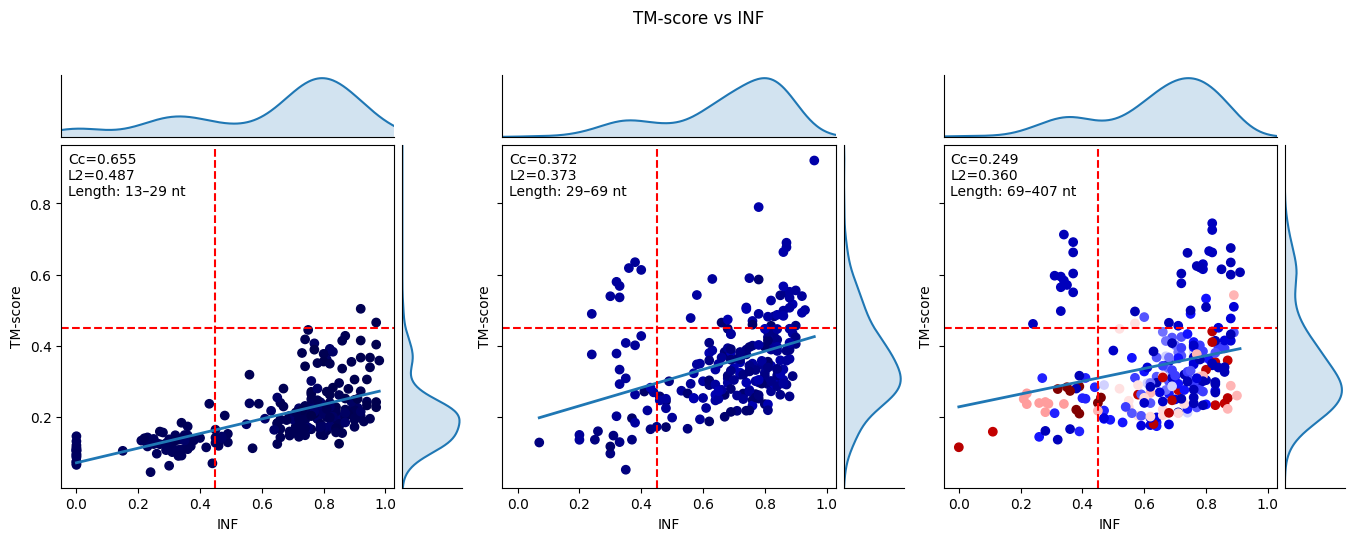

In [55]:
plot_tertiles_three_panels(
    "INF-ALL",
    "TM-scoreRNA",
    "TM-score vs INF",
    ylabel="TM-score",
    xlabel="INF",
    x_threshold=0.45,
    y_threshold=0.45
)

### Figure 3

#### Figure 3B - identify the best models according to all 4 metrics

In [ ]:
per_id_csv = "../OUTPUTS/figures/Table-S5-perID.csv"
df = pd.read_csv(per_id_csv)

success_cols = ['TM Success', 'GDT Success', 'INF Success', 'lDDT Success']
for col in success_cols:
    df[col] = df[col].astype(bool)

df['n_success'] = df[success_cols].sum(axis=1)

# filter 
success_df = df[df['n_success'] >= 4]

# order
success_df = success_df.sort_values(by='TM-scoreRNA', ascending=False)

# cols to show
success_df = success_df[['PDB_ID', 'Model', 'TM-scoreRNA'] + success_cols]

print("Number of models with ≥3 successes:", len(success_df))
print(success_df)


Number of models with ≥3 successes: 15
    PDB_ID         Model  TM-scoreRNA  TM Success  GDT Success  INF Success  \
511  R1263         RF2NA      0.92072        True         True         True   
683  R1263  trRosettaRNA      0.78980        True         True         True   
24    8FCS           AF3      0.67471        True         True         True   
368   8FCS        NuFold      0.63414        True         True         True   
110   8FCS       Boltz-1      0.61500        True         True         True   
196   8FCS          Chai      0.59979        True         True         True   
367   8FB3        NuFold      0.58616        True         True         True   
382   8Q6N        NuFold      0.54175        True         True         True   
319   9DE6           HF3      0.53952        True         True         True   
145   9BLM       Boltz-1      0.51669        True         True         True   
149   9ECQ       Boltz-1      0.50386        True         True         True   
62    9DE7   

#### Fig 3A - Venn Diagrams

In [26]:
def figure3(input_dir, output_dir):

    os.makedirs(output_dir, exist_ok=True)

    per_id_csv = os.path.join(input_dir, "Table-S5-perID.csv")
    df = pd.read_csv(per_id_csv)

    def to_bool(s):
        if s.dtype == bool:
            return s
        s2 = s.astype(str).str.strip().str.lower()
        return s2.isin(["true", "1", "yes", "y", "t"])

    for col in ["TM Success", "GDT Success", "INF Success", "lDDT Success"]:
        df[col] = to_bool(df[col])

    set_order = [
        ("TM", "TM Success"),
        ("GDT-TS", "GDT Success"),
        ("INF", "INF Success"),
        ("lDDT", "lDDT Success"),
    ]

    cmap = ListedColormap(["blue", "orange", "pink", "darkgreen"])

    def build_sets(d):
        return {
            label: set(d.loc[d[col], "PDB_ID"].astype(str))
            for label, col in set_order
        }

    def safe_name(name):
        return re.sub(r"[^A-Za-z0-9._+-]+", "-", str(name))

    # all methods together
    plt.figure(figsize=(7, 7))
    venn(build_sets(df), cmap=cmap)
    plt.title("Success Rate Venn Diagram (All methods)", fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "Fig-3A.png"), dpi=300, bbox_inches="tight")
    plt.close()

    # one per method
    for method in sorted(df["Model"].dropna().unique()):
        d = df[df["Model"] == method]

        plt.figure(figsize=(7, 7))
        venn(build_sets(d), cmap=cmap)
        plt.title(f"Success Rate Venn Diagram for {method}", fontsize=16)
        plt.tight_layout()
        plt.savefig(
            os.path.join(output_dir, f"Fig-S7-{safe_name(method)}.png"),
            dpi=300,
            bbox_inches="tight"
        )
        plt.close()

    print(f"Saved: {os.path.join(output_dir, 'Fig-3A.png')}")
    for method in sorted(df["Model"].dropna().unique()):
        print(f"Saved: {os.path.join(output_dir, f'Fig-S7-{safe_name(method)}.png')}")

In [27]:
figure3(
    input_dir="../OUTPUTS/figures",
    output_dir="../OUTPUTS/figures"
)

Saved: ../OUTPUTS/figures/Fig-3A.png
Saved: ../OUTPUTS/figures/Fig-S7-AF3.png
Saved: ../OUTPUTS/figures/Fig-S7-Boltz-1.png
Saved: ../OUTPUTS/figures/Fig-S7-Chai.png
Saved: ../OUTPUTS/figures/Fig-S7-HF3.png
Saved: ../OUTPUTS/figures/Fig-S7-NuFold.png
Saved: ../OUTPUTS/figures/Fig-S7-RF2NA.png
Saved: ../OUTPUTS/figures/Fig-S7-RhoFold+.png
Saved: ../OUTPUTS/figures/Fig-S7-trRosettaRNA.png


<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

### Figure 5

In [31]:
def figure5(input_dir, output_dir):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import seaborn as sns

    mpl.rcParams["font.family"] = "serif"
    mpl.rcParams["font.serif"] = ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"]
    sns.set_style("whitegrid")
    sns.set_context("talk")

    os.makedirs(output_dir, exist_ok=True)

    af3_csv = os.path.join(input_dir, "af3-single.csv")
    method_files = {
        "AF3": "af3-single.csv",
        "HF3": "hf3-single.csv",
        "RF2NA": "rf2na-single.csv",
        "RhoFold+": "rhofold-single.csv",
        "NuFold": "nufold-single.csv",
        "trRosettaRNA": "trrosetta-single.csv",
    }

    tm_col = "TM-scoreRNA"
    msa_col = "MSA_depth"
    out_png = os.path.join(output_dir, "Fig-5.png")

    def msa_bin(v):
        if 0 <= v <= 5:
            return "MSA depth 0–5"
        if 5 < v <= 15:
            return "MSA depth 5–15"
        if 15 < v <= 100:
            return "MSA depth 15–100"
        if 100 < v <= 1000:
            return "MSA depth 100–1000"
        return "MSA depth >1000"

    x_order = [
        "MSA depth 0–5",
        "MSA depth 5–15",
        "MSA depth 15–100",
        "MSA depth 100–1000",
        "MSA depth >1000",
    ]

    palette = {
        "AF3": "#1f77b4",
        "HF3": "#98df8a",
        "RF2NA": "#ffbb78",
        "RhoFold+": "#d62728",
        "NuFold": "#ff7f0e",
        "trRosettaRNA": "#ff9896",
    }

    # get MSA info
    df_src = pd.read_csv(af3_csv, usecols=["PDB_ID", msa_col]).copy()
    df_src[msa_col] = pd.to_numeric(df_src[msa_col], errors="coerce")
    df_src = df_src.dropna(subset=[msa_col])
    df_src = df_src[df_src[msa_col] > 0].copy()
    df_src["MSA_bin_label"] = df_src[msa_col].apply(msa_bin)

    # merge all methods
    frames = []
    for model, filename in method_files.items():
        path = os.path.join(input_dir, filename)
        df = pd.read_csv(path, usecols=["PDB_ID", tm_col]).copy()
        df[tm_col] = pd.to_numeric(df[tm_col], errors="coerce")
        df = df.dropna(subset=[tm_col])

        merged = df.merge(df_src[["PDB_ID", "MSA_bin_label"]], on="PDB_ID", how="inner")
        if merged.empty:
            continue

        merged["Model"] = model
        frames.append(merged)

    if not frames:
        raise RuntimeError("No data to plot.")

    df_long = pd.concat(frames, ignore_index=True)
    df_long["MSA_bin_label"] = pd.Categorical(df_long["MSA_bin_label"], categories=x_order, ordered=True)
    model_order = [m for m in method_files if m in df_long["Model"].unique()]

    # plot
    plt.figure(figsize=(19, 6))
    ax = sns.violinplot(
        data=df_long,
        x="MSA_bin_label",
        y=tm_col,
        hue="Model",
        order=x_order,
        hue_order=model_order,
        palette=palette,
        width=0.8,
        cut=0,
        scale="width",
        inner="box",
        linewidth=1,
    )

    ax.grid(True)
    ax.set_xlabel("")
    ax.set_ylabel("TM-score", fontsize=18, fontweight="bold")
    ax.set_title("Prediction accuracy dependence on MSA depth", fontsize=19, fontweight="normal", pad=15)
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", labelsize=15)
    ax.tick_params(axis="y", labelsize=15)
    sns.despine(ax=ax, top=True, right=True)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:len(model_order)],
        labels[:len(model_order)],
        title="",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=13,
    )

    # count
    print("\nNumber of examples per MSA depth category:")
    bin_counts = df_long.groupby("MSA_bin_label").size().reindex(x_order)

    for label, count in bin_counts.items():
        print(f"{label}: {count}")

    for i, label in enumerate(x_order):
        ax.text(
            i,
            -0.08,
            f"N={bin_counts[label]}",
            ha="center",
            va="top",
            fontsize=13,
            transform=ax.get_xaxis_transform(),
        )

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved: {out_png}")
    print("Using fixed MSA depth bins: 0–5, 5–15, 15–100, 100–1000, >1000")

In [32]:
figure5(
    input_dir="../OUTPUTS/single",
    output_dir="../OUTPUTS/figures"
)

/tmp/ipykernel_978566/3757938586.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(



Number of examples per MSA depth category:
MSA depth 0–5: 138
MSA depth 5–15: 42
MSA depth 15–100: 156
MSA depth 100–1000: 78
MSA depth >1000: 102


/tmp/ipykernel_978566/3757938586.py:126: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_long.groupby("MSA_bin_label").size().reindex(x_order)


Saved: ../OUTPUTS/figures/Fig-5.png
Using fixed MSA depth bins: 0–5, 5–15, 15–100, 100–1000, >1000


## COMPLEXES

### Figure 5

In [35]:
def plot_tm_dockq_complexes(
    input_dir,
    output_dir
):
    """
    Generate TM-Score and DockQ violin plots with consistent ordering and model-specific colors.
    """

    os.makedirs(output_dir, exist_ok=True)

    custom_labels = {
        'dockq-af3': 'AF3',
        'dockq-hf3': 'HF3',
        'dockq-rf2na': 'RF2NA',
        'dockq-boltz': 'Boltz'
    }

    # Load TM-Score and DockQ data
    tm_dict = {}
    dockq_dict = {}

    csv_files = [f for f in os.listdir(input_dir) if f.endswith('.csv')]

    for file in csv_files:
        file_path = os.path.join(input_dir, file)
        df = pd.read_csv(file_path)
        base_name = file.replace('.csv', '')
        model_name = custom_labels.get(base_name, base_name)

        # TM data
        tm_df = df[['PDB_ID', 'TM_Score']].copy()
        tm_df['Model'] = model_name
        tm_df = tm_df.drop_duplicates(subset='PDB_ID')
        tm_dict[base_name] = tm_df

        # DockQ data
        dockq_df = df[['PDB_ID', 'Total_DockQ_Score']].rename(
            columns={'Total_DockQ_Score': 'DockQ_Score'}
        ).copy()
        dockq_df['Model'] = model_name
        dockq_dict[base_name] = dockq_df

    # Find common PDB IDs
    common_ids = set(tm_dict['dockq-af3']['PDB_ID'])
    for key in tm_dict.keys():
        common_ids &= set(tm_dict[key]['PDB_ID'])

    for key in tm_dict.keys():
        tm_dict[key] = tm_dict[key][tm_dict[key]['PDB_ID'].isin(common_ids)]
        dockq_dict[key] = dockq_dict[key][dockq_dict[key]['PDB_ID'].isin(common_ids)]

    tm_combined = pd.concat(tm_dict.values(), ignore_index=True)
    dockq_combined = pd.concat(dockq_dict.values(), ignore_index=True)

    num_common_ids = len(common_ids)

    # order by TM-score
    model_tm_means = tm_combined.groupby('Model')['TM_Score'].mean().sort_values(ascending=False)
    sorted_models_tm = model_tm_means.index.tolist()

    # colors
    color_list = sns.color_palette("Set2", len(sorted_models_tm))
    palette_dict = {model: color_list[i] for i, model in enumerate(sorted_models_tm)}

    # tm plot 
    plt.figure(figsize=(13, 7))
    sns.violinplot(
        x='Model',
        y='TM_Score',
        data=tm_combined,
        order=sorted_models_tm,
        palette=palette_dict,
        width=0.8,
        cut=0,
        scale='width'
    )
    plt.ylabel('USAlign TM-Score', fontsize=18, fontweight='bold')
    plt.xlabel('')
    plt.title('RNA/RNA/Protein Complex Prediction Accuracy', fontsize=20)
    plt.xticks(fontsize=17, fontweight='bold')
    plt.tight_layout()

    plt.savefig(os.path.join(output_dir, "Fig-6A.png"))
    plt.close()

    # dockq plot
    plt.figure(figsize=(14, 7))
    sns.violinplot(
        x='Model',
        y='DockQ_Score',
        data=dockq_combined,
        order=sorted_models_tm,
        palette=palette_dict,
        width=0.8,
        cut=0,
        scale='width'
    )
    plt.ylabel('DockQ Score', fontsize=18, fontweight='bold')
    plt.xlabel('')
    plt.title('RNA/RNA/Protein Complex DockQ', fontsize=20)
    plt.xticks(fontsize=17, fontweight='bold')
    plt.tight_layout()

    plt.savefig(os.path.join(output_dir, "Fig-6B.png"))
    plt.close()

    # summary csv
    summary_records = []

    for model in sorted_models_tm:
        tm_scores = tm_combined[tm_combined['Model'] == model]
        dockq_scores = dockq_combined[dockq_combined['Model'] == model]

        mean_tm = tm_scores['TM_Score'].mean()
        mean_dockq = dockq_scores['DockQ_Score'].mean()
        count = tm_scores['PDB_ID'].nunique()

        high_quality = dockq_scores[dockq_scores['DockQ_Score'] > 0.23]['PDB_ID'].nunique()
        success_rate = (high_quality / num_common_ids) * 100

        summary_records.append({
            'Method': model,
            'Mean TM_Score': round(mean_tm, 3),
            'Mean DockQ_Score': round(mean_dockq, 3),
            'Count': count,
            'Success_rate_dockq': round(success_rate, 1)
        })

    summary_df = pd.DataFrame(summary_records)
    summary_df.to_csv(os.path.join(output_dir, "Table-S5.csv"), index=False)


In [40]:
plot_tm_dockq_complexes(
    input_dir="../OUTPUTS/complex",
    output_dir="../OUTPUTS/figures"
)

/tmp/ipykernel_978566/28223827.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_978566/28223827.py:67: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_978566/28223827.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_978566/28223827.py:88: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


In [42]:
def interface_violinplots(input_dir: str, output_dir: str) -> None:
    """
    Creates and saves a violin plot of DockQ scores grouped by model and interaction type,
    and outputs mean scores as a CSV file.

    Parameters:
    - input_dir: Path to the directory containing the input CSV files.
    - output_dir: Path to the directory where the output figure and table will be saved.
    """

    file_labels = {
        'dockq-af3.csv': 'AF3',
        'dockq-hf3.csv': 'HF3',
        'dockq-rf2na.csv': 'RF2NA',
        'dockq-boltz.csv': 'Boltz'
    }

    df_list = []
    pdb_type_sets = []

    # Load and process each CSV
    for file_name, model_label in file_labels.items():
        file_path = os.path.join(input_dir, file_name)
        df = pd.read_csv(file_path)
        df['Model'] = model_label

        # Normalize Type
        df['Type'] = df['Type'].str.lower().replace({
            'rna, protein': 'RNA/Protein',
            'protein, rna': 'RNA/Protein',
            'rna, rna': 'RNA/RNA'
        })

        # Keep only RNA/Protein and RNA/RNA
        df = df[df['Type'].isin(['RNA/Protein', 'RNA/RNA'])]

        # Track (PDB_ID, Type)
        pdb_type_sets.append(set(zip(df['PDB_ID'], df['Type'])))

        df_list.append(df[['PDB_ID', 'DockQ_Score', 'Type', 'Model']])

    # Find common (PDB_ID, Type) pairs across all models
    common_pairs = set.intersection(*pdb_type_sets)

    # Combine all data and filter by common pairs
    combined_df = pd.concat(df_list, ignore_index=True)
    combined_df['Pair'] = list(zip(combined_df['PDB_ID'], combined_df['Type']))
    combined_df = combined_df[combined_df['Pair'].isin(common_pairs)].drop(columns='Pair')

    # Create combined Model-Type column
    combined_df['Model_Type'] = combined_df['Model'] + '-' + combined_df['Type']

    # Order models by mean DockQ for RNA/Protein
    ordered_models = (
        combined_df[combined_df['Type'] == 'RNA/Protein']
        .groupby('Model')['DockQ_Score']
        .mean()
        .sort_values(ascending=False)
        .index.tolist()
    )

    # Build x-axis order
    model_type_order = []
    for model in ordered_models:
        model_type_order.append(model + '-RNA/Protein')
        model_type_order.append(model + '-RNA/RNA')

    # === METHOD-LEVEL COLORS (match your other figure) ===
    # Use the same palette as in your TM/DockQ function, e.g. Set2 with 4 colors
    base_palette = sns.color_palette("Set2", 4)
    method_order = ['AF3', 'HF3', 'RF2NA', 'Boltz']
    method_colors = {
    "AF3":   "#71b6a1",
    "HF3":   "#db96c0",   # put the color you want HF3 to be
    "RF2NA": "#95a3c3",
    "Boltz": "#e99675",   # put the color you want Boltz to be
}


    # Build palette for Model_Type: color based only on method
    palette = {}
    for mt in model_type_order:
        model_name, _ = mt.split('-', 1)  # e.g. "AF3-RNA/Protein" -> "AF3"
        palette[mt] = method_colors.get(model_name, 'grey')

    # Plot
    plt.figure(figsize=(14, 6))

    sns.violinplot(
        x='Model_Type',
        y='DockQ_Score',
        data=combined_df,
        order=model_type_order,
        cut=0,
        palette=palette,
        width=0.6
    )

    # Add vertical separators between methods
    for i in range(1, len(model_type_order), 2):
        plt.axvline(x=i + 0.5, color='gray', linestyle='--', linewidth=0.8)

    # Formatting
    plt.xticks(
        range(len(model_type_order)),
        model_type_order,
        fontsize=13, rotation=0, ha='center'
    )
    plt.ylabel('DockQ Score', fontsize=14, fontweight='bold')
    plt.xlabel('')
    plt.title('Individual Chain Interface DockQ Scores by Interaction Type', fontsize=15)
    plt.tight_layout()

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Save figure
    output_figure_path = os.path.join(output_dir, 'Fig-6C.png')
    plt.savefig(output_figure_path, dpi=300)
    plt.close()

    # Compute mean DockQ scores
    mean_by_type = (
        combined_df
        .groupby(['Model', 'Type'])['DockQ_Score']
        .mean()
        .reset_index()
        .pivot(index='Model', columns='Type', values='DockQ_Score')
    )

    mean_combined = (
        combined_df
        .groupby('Model')['DockQ_Score']
        .mean()
        .rename('Combined')
    )

    mean_scores = mean_by_type.merge(mean_combined, left_index=True, right_index=True)

    # Save mean scores table
    output_table_path = os.path.join(output_dir, 'Table-S8-S9.csv')
    mean_scores.round(3).to_csv(output_table_path)


In [43]:
interface_violinplots(
    input_dir="../OUTPUTS/complex",
    output_dir="../OUTPUTS/figures"
)

/tmp/ipykernel_978566/1470948001.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


### Figure 7

In [41]:

def plot_tm_dockq_scatter(input_dir, output_dir):

    os.makedirs(output_dir, exist_ok=True)
    sns.set(style="white")

    custom_labels = {
        'dockq-af3': 'AF3',
        'dockq-hf3': 'HF3',
        'dockq-rf2na': 'RF2NA',
        'dockq-boltz': 'Boltz'
    }

    def infer_max_scale(x, y):
        """Choose a reasonable max axis value based on the data."""
        maxval = max(x.max(), y.max())
        if maxval < 1:
            return 1.0
        if maxval > 30:
            return 100.0
        return float(maxval)

    def add_moving_averages(df, x_col, y_col, window=10):
        """Add rolling mean columns for x and y."""
        df = df.sort_values(by=x_col).reset_index(drop=True)
        df[f"moving_avg_{x_col}"] = df[x_col].rolling(window=window).mean()
        df[f"moving_avg_{y_col}"] = df[y_col].rolling(window=window).mean()
        return df

    def annotate_outliers(ax, df, x_col, y_col, id_col, cutoff):
        """Label points where |x - y| exceeds the cutoff."""
        for _, row in df.iterrows():
            if abs(row[x_col] - row[y_col]) > cutoff:
                ax.text(
                    row[x_col],
                    row[y_col],
                    row[id_col],
                    fontsize=8,
                    alpha=0.7,
                )

    def add_stats_box(ax, x, y, maxval, label_x, label_y):
        """Add correlation, p-value and means in a text box."""
        t_stat, p_value = ttest_rel(x, y)
        corr = np.corrcoef(x, y)[0, 1]
        mean_x = x.mean()
        mean_y = y.mean()

        ax.text(
            maxval * 0.05,
            maxval * 0.85,
            f"Cc: {corr:.2f}\n"
            f"p: {p_value:.4e}\n"
            f"<{label_x}>: {mean_x:.2f}\n"
            f"<{label_y}>: {mean_y:.2f}",
            fontsize=10,
        )

    dfs = {}
    common_pdb_ids = None

    for fname in os.listdir(input_dir):
        if not fname.endswith(".csv"):
            continue

        base = fname.split(".")[0]
        if base not in custom_labels:
            continue

        model_label = custom_labels[base]
        df = pd.read_csv(os.path.join(input_dir, fname))
        df["Model"] = model_label
        dfs[model_label] = df

        pdb_ids = set(df["PDB_ID"])
        common_pdb_ids = pdb_ids if common_pdb_ids is None else (common_pdb_ids & pdb_ids)

    if "AF3" not in dfs:
        raise ValueError("AF3 model CSV is required for baseline comparisons.")

    if not common_pdb_ids:
        raise ValueError("No common PDB IDs found among models.")

    # only common IDs
    for model in dfs:
        dfs[model] = (
            dfs[model]
            .loc[dfs[model]["PDB_ID"].isin(common_pdb_ids)]
            .drop_duplicates(subset=["PDB_ID"])
        )

    combined_tm_data = pd.concat(dfs.values(), ignore_index=True)

    # tm scatter
    tm_pivot = combined_tm_data.pivot(
        index="PDB_ID", columns="Model", values="TM_Score"
    ).reset_index()

    other_methods = [label for label in custom_labels.values() if label != "AF3"]

    for method in other_methods:
        if method not in tm_pivot.columns:
            print(f"Skipping {method} for TM-score, not found in data.")
            continue

        plot_df = tm_pivot.dropna(subset=["AF3", method]).copy()
        if plot_df.empty:
            print(f"No valid TM-score pairs for AF3 vs {method}.")
            continue

        plot_df = add_moving_averages(plot_df, "AF3", method)

        jp = sns.jointplot(
            data=plot_df,
            x="AF3",
            y=method,
            kind="scatter",
            height=7,
            space=0,
        )

        maxval = infer_max_scale(plot_df["AF3"], plot_df[method])

        sns.lineplot(
            x=[0, maxval],
            y=[0, maxval],
            ax=jp.ax_joint,
            linestyle="--",
            color="red",
        )

        # moving average curve
        sns.lineplot(
            data=plot_df,
            x="moving_avg_AF3",
            y=f"moving_avg_{method}",
            ax=jp.ax_joint,
            color="purple",
        )

        # label outliers
        cutoff = maxval / 10.0
        annotate_outliers(jp.ax_joint, plot_df, "AF3", method, "PDB_ID", cutoff)

        add_stats_box(jp.ax_joint, plot_df["AF3"], plot_df[method], maxval, "AF3", method)

        jp.figure.suptitle(f"AF3 vs {method} TM-Score", fontsize=14)
        jp.figure.subplots_adjust(top=0.95)
        jp.ax_joint.set_xlabel("TM-score (AF3)", fontsize=12)
        jp.ax_joint.set_ylabel(f"TM-score ({method})", fontsize=12)

        if method == "Boltz":
            fig_name = "Fig-7A.png"
        else:
            fig_name = f"Fig-S9-AF3-{method}-tm.png"

        jp.figure.savefig(os.path.join(output_dir, fig_name))
        plt.close(jp.figure)

    # DOCKQ SCATTER PLOTS

    dockq_only = {}

    for model, df in dfs.items():
        if "Total_DockQ_Score" not in df.columns:
            print(f"Skipping {model} for DockQ: 'Total_DockQ_Score' not found.")
            continue

        tmp = df[["PDB_ID", "Total_DockQ_Score"]].copy()
        tmp = tmp.drop_duplicates(subset=["PDB_ID"])
        tmp["Model"] = model
        dockq_only[model] = tmp

    if "AF3" not in dockq_only:
        raise ValueError("AF3 DockQ CSV is required (must contain 'Total_DockQ_Score').")

    # common IDs
    common_dockq_ids = set(dockq_only["AF3"]["PDB_ID"])
    for model, tmp in dockq_only.items():
        common_dockq_ids &= set(tmp["PDB_ID"])

    if not common_dockq_ids:
        raise ValueError("No common PDB IDs found among models for Total_DockQ_Score.")

    for model in dockq_only:
        dockq_only[model] = dockq_only[model].loc[
            dockq_only[model]["PDB_ID"].isin(common_dockq_ids)
        ]

    combined_dockq_data = pd.concat(dockq_only.values(), ignore_index=True)

    dockq_pivot = combined_dockq_data.pivot(
        index="PDB_ID", columns="Model", values="Total_DockQ_Score"
    ).reset_index()

    for model in ["HF3", "RF2NA", "Boltz"]:
        if model not in dockq_pivot.columns:
            print(f"Skipping {model} for DockQ, not found in data.")
            continue

        plot_df = dockq_pivot.dropna(subset=["AF3", model]).copy()
        if plot_df.empty:
            print(f"No valid Total_DockQ_Score pairs for AF3 vs {model}.")
            continue

        plot_df = add_moving_averages(plot_df, "AF3", model)

        jp = sns.jointplot(
            data=plot_df,
            x="AF3",
            y=model,
            kind="scatter",
            height=7,
            space=0,
        )

        maxval = infer_max_scale(plot_df["AF3"], plot_df[model])

        sns.lineplot(
            x=[0, maxval],
            y=[0, maxval],
            ax=jp.ax_joint,
            linestyle="--",
            color="red",
        )

        sns.lineplot(
            data=plot_df,
            x="moving_avg_AF3",
            y=f"moving_avg_{model}",
            ax=jp.ax_joint,
            color="purple",
        )

        cutoff = maxval / 10.0
        annotate_outliers(jp.ax_joint, plot_df, "AF3", model, "PDB_ID", cutoff)

        add_stats_box(
            jp.ax_joint,
            plot_df["AF3"],
            plot_df[model],
            maxval,
            "AF3",
            model,
        )

        jp.figure.suptitle(f"AF3 vs {model} DockQ", fontsize=14)
        jp.figure.subplots_adjust(top=0.95)
        jp.ax_joint.set_xlabel("DockQ (AF3)", fontsize=12)
        jp.ax_joint.set_ylabel(f"DockQ ({model})", fontsize=12)

        if model == "Boltz":
            fig_name = "Fig-7B.png"
        else:
            fig_name = f"Fig-S9-AF3-{model}-dockq.png"

        jp.figure.savefig(os.path.join(output_dir, fig_name))
        plt.close(jp.figure)

plot_tm_dockq_scatter(
    input_dir="../OUTPUTS/complex",
    output_dir="../OUTPUTS/figures"
)

### Figure 8

In [44]:
def figure8(input_dir, output_dir):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import spearmanr

    sns.set(style="white")
    os.makedirs(output_dir, exist_ok=True)

    files = {
        "dockq-af3.csv": ("AF3", "Fig-8A.png"),
        "dockq-boltz.csv": ("Boltz", "Fig-8B.png"),
        "dockq-hf3.csv": ("HF3", "Fig-8C.png"),
        "dockq-rf2na.csv": ("RF2NA", "Fig-8D.png"),
    }

    palette = {
        "rna, rna": "#ee82ee",
        "rna, protein": "#1f77b4",
        "rna, dna": "#2ca02c",
        "rna, protein, dna": "#ff7f0e",
        "protein, protein": "#8c564b",
        "dna, dna": "#7f7f7f",
        "unknown": "#000000",
    }

    def normalize_type_string(t):
        if pd.isna(t):
            return ""
        s = str(t).strip().lower().replace(";", ",").replace("/", ",").replace("|", ",")
        tokens = [x.strip() for x in s.split(",") if x.strip()]

        norm = []
        for x in tokens:
            if x in {"prot", "protein"}:
                norm.append("protein")
            elif x == "rna":
                norm.append("rna")
            elif x == "dna":
                norm.append("dna")

        return ", ".join(sorted(set(norm)))

    def components_from_type_series(types):
        comps = set()
        for t in types.dropna().astype(str):
            nt = normalize_type_string(t)
            if nt:
                comps.update(x.strip() for x in nt.split(",") if x.strip())
        return comps

    def whole_complex_label_from_components(comps):
        if not comps:
            return "unknown"

        present = [x for x in ["rna", "protein", "dna"] if x in comps]
        present_set = set(present)

        if present_set == {"rna"}:
            return "rna, rna"
        if present_set == {"rna", "protein", "dna"}:
            return "rna, protein, dna"
        if present_set == {"rna", "protein"}:
            return "rna, protein"
        if present_set == {"rna", "dna"}:
            return "rna, dna"
        if present_set == {"protein"}:
            return "protein, protein"
        if present_set == {"dna"}:
            return "dna, dna"

        return ", ".join(present)

    def agg_whole_type(type_series):
        comps = components_from_type_series(type_series)
        return whole_complex_label_from_components(comps)

    for filename, (method_name, out_name) in files.items():
        filepath = os.path.join(input_dir, filename)
        df = pd.read_csv(filepath)

        need_cols = ["PDB_ID", "TM_Score", "Total_DockQ_Score", "Type"]
        missing = [c for c in need_cols if c not in df.columns]
        if missing:
            print(f"{method_name}: missing columns {missing}, skipping.")
            continue

        df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=need_cols)

        grouped = (
            df.groupby("PDB_ID", as_index=False)
            .agg(
                TM_Score=("TM_Score", "first"),
                Total_DockQ_Score=("Total_DockQ_Score", "first"),
                WholeType=("Type", agg_whole_type),
                InterfaceTypes=("Type", lambda s: sorted(set(normalize_type_string(x) for x in s.dropna()))),
            )
        )

        if grouped.empty:
            print(f"No data left after filtering for {method_name}, skipping.")
            continue

        mixed = grouped[grouped["InterfaceTypes"].apply(lambda x: len(x) > 1)]
        print(f"\n[{method_name}] N unique complexes: {len(grouped)}")
        print(f"[{method_name}] WholeType counts:\n{grouped['WholeType'].value_counts(dropna=False)}")
        print(f"[{method_name}] Mixed interface-type complexes: {len(mixed)}")
        if len(mixed) > 0:
            print(mixed[["PDB_ID", "WholeType", "InterfaceTypes"]].head(10).to_string(index=False))

        cc, _ = spearmanr(grouped["TM_Score"], grouped["Total_DockQ_Score"])

        g = sns.JointGrid(data=grouped, x="TM_Score", y="Total_DockQ_Score", height=7)

        sns.scatterplot(
            data=grouped,
            x="TM_Score",
            y="Total_DockQ_Score",
            hue="WholeType",
            palette=palette,
            alpha=0.8,
            s=60,
            ax=g.ax_joint,
        )

        sns.kdeplot(
            data=grouped,
            x="TM_Score",
            hue="WholeType",
            palette=palette,
            fill=True,
            alpha=0.35,
            common_norm=False,
            ax=g.ax_marg_x,
            legend=False,
        )
        sns.kdeplot(
            data=grouped,
            y="Total_DockQ_Score",
            hue="WholeType",
            palette=palette,
            fill=True,
            alpha=0.35,
            common_norm=False,
            ax=g.ax_marg_y,
            legend=False,
        )

        g.ax_joint.plot([0, 1], [0, 1], linestyle="--", color="red", linewidth=1)
        g.ax_joint.text(
            0.05, 0.95,
            f"Cc: {cc:.2f}",
            transform=g.ax_joint.transAxes,
            fontsize=12,
            va="top",
        )

        g.set_axis_labels("TM-Score", "Total DockQ", fontsize=13)
        g.figure.suptitle(f"TM-Score vs Total DockQ: {method_name}", fontsize=14)
        g.figure.subplots_adjust(top=0.95)
        g.ax_joint.legend(title="Type", loc="best")

        out_path = os.path.join(output_dir, out_name)
        g.figure.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.close(g.figure)

        print(f"Saved: {out_path}")

In [47]:
figure8(
    input_dir="../OUTPUTS/complex",
    output_dir="../OUTPUTS/figures"
)


[AF3] N unique complexes: 158
[AF3] WholeType counts:
WholeType
rna, protein         85
rna, protein, dna    45
rna, rna             27
rna, dna              1
Name: count, dtype: int64
[AF3] Mixed interface-type complexes: 93
PDB_ID         WholeType                              InterfaceTypes
  7DA7      rna, protein                     [protein, protein, rna]
  7QR3      rna, protein                         [protein, rna, rna]
  7SC6      rna, protein                     [protein, protein, rna]
  7SCQ      rna, protein                     [protein, protein, rna]
  7TNX      rna, protein                         [protein, rna, rna]
  7TNY      rna, protein                         [protein, rna, rna]
  7TO0      rna, protein                         [protein, rna, rna]
  7U2A      rna, protein                     [protein, protein, rna]
  7UU3      rna, protein                         [protein, rna, rna]
  7V94 rna, protein, dna [dna, dna, protein, dna, rna, protein, rna]


/tmp/ipykernel_978566/1175779858.py:128: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_978566/1175779858.py:139: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved: ../OUTPUTS/figures/Fig-8A.png

[Boltz] N unique complexes: 158
[Boltz] WholeType counts:
WholeType
rna, protein         85
rna, protein, dna    45
rna, rna             27
rna, dna              1
Name: count, dtype: int64
[Boltz] Mixed interface-type complexes: 93
PDB_ID         WholeType                              InterfaceTypes
  7DA7      rna, protein                     [protein, protein, rna]
  7QR3      rna, protein                         [protein, rna, rna]
  7SC6      rna, protein                     [protein, protein, rna]
  7SCQ      rna, protein                     [protein, protein, rna]
  7TNX      rna, protein                         [protein, rna, rna]
  7TNY      rna, protein                         [protein, rna, rna]
  7TO0      rna, protein                         [protein, rna, rna]
  7U2A      rna, protein                     [protein, protein, rna]
  7UU3      rna, protein                         [protein, rna, rna]
  7V94 rna, protein, dna [dna, dna, pro

/tmp/ipykernel_978566/1175779858.py:128: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_978566/1175779858.py:139: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved: ../OUTPUTS/figures/Fig-8B.png

[HF3] N unique complexes: 158
[HF3] WholeType counts:
WholeType
rna, protein         84
rna, protein, dna    46
rna, rna             27
rna, dna              1
Name: count, dtype: int64
[HF3] Mixed interface-type complexes: 93
PDB_ID         WholeType                              InterfaceTypes
  7DA7      rna, protein                     [protein, protein, rna]
  7QR3      rna, protein                         [protein, rna, rna]
  7SC6      rna, protein                     [protein, protein, rna]
  7SCQ      rna, protein                     [protein, protein, rna]
  7TNX      rna, protein                         [protein, rna, rna]
  7TNY      rna, protein                         [protein, rna, rna]
  7TO0      rna, protein                         [protein, rna, rna]
  7U2A      rna, protein                     [protein, protein, rna]
  7UU3      rna, protein                         [protein, rna, rna]
  7V94 rna, protein, dna [dna, dna, protein, 

/tmp/ipykernel_978566/1175779858.py:128: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_978566/1175779858.py:139: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved: ../OUTPUTS/figures/Fig-8C.png

[RF2NA] N unique complexes: 158
[RF2NA] WholeType counts:
WholeType
rna, protein         86
rna, protein, dna    44
rna, rna             27
rna, dna              1
Name: count, dtype: int64
[RF2NA] Mixed interface-type complexes: 93
PDB_ID         WholeType                              InterfaceTypes
  7DA7      rna, protein                     [protein, protein, rna]
  7QR3      rna, protein                         [protein, rna, rna]
  7SC6      rna, protein                     [protein, protein, rna]
  7SCQ      rna, protein                     [protein, protein, rna]
  7TNX      rna, protein                         [protein, rna, rna]
  7TNY      rna, protein                         [protein, rna, rna]
  7TO0      rna, protein                         [protein, rna, rna]
  7U2A      rna, protein                     [protein, protein, rna]
  7UU3      rna, protein                         [protein, rna, rna]
  7V94 rna, protein, dna [dna, dna, pro

/tmp/ipykernel_978566/1175779858.py:128: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_978566/1175779858.py:139: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved: ../OUTPUTS/figures/Fig-8D.png


## Figure 9 - Confidence Metrics (single/complexes)

In [48]:

def ptm_vs_tm(input_dir: str, output_dir: str):
    os.makedirs(output_dir, exist_ok=True)

    files = ["af3-single.csv", "boltz-single.csv", "hf3-single.csv", "chai-single.csv"]
    labels = ["AF3", "Boltz", "HF3", "Chai"]
    output_names = ["Fig-9A.png", "Fig-S11A.png", "Fig-S11C.png", "Fig-S11E.png"]

    # Load all data
    all_data = []
    for file, label in zip(files, labels):
        df = pd.read_csv(os.path.join(input_dir, file))
        df = df[["PDB_ID", "ptm", "TM-scoreRNA"]].dropna()
        df = df.drop_duplicates(subset="PDB_ID", keep="first")
        df["method"] = label
        all_data.append(df)

    # Find common PDB_IDs across all datasets
    common_ids = set(all_data[0]["PDB_ID"])
    for df in all_data[1:]:
        common_ids &= set(df["PDB_ID"])

    # Filter to common IDs
    filtered_data = [df[df["PDB_ID"].isin(common_ids)].copy() for df in all_data]

    # Generate individual plots
    sns.set(style="white")
    for df, label, out_name in zip(filtered_data, labels, output_names):
        df.rename(columns={"ptm": "pTM", "TM-scoreRNA": "TM"}, inplace=True)
        df = df.replace([np.inf, -np.inf], np.nan).dropna()

        g = sns.JointGrid(data=df, x="pTM", y="TM", height=7, space=0)

        # Scatter plot
        g.plot_joint(sns.scatterplot, s=60, alpha=0.8, color="#d382ee")

        # Marginal KDEs
        sns.kdeplot(data=df, x="pTM", ax=g.ax_marg_x, fill=True, alpha=0.4, color="#d382ee")
        sns.kdeplot(data=df, y="TM", ax=g.ax_marg_y, fill=True, alpha=0.4, color="#d382ee")

        # Diagonal reference
        maxval = max(df["pTM"].max(), df["TM"].max())
        g.ax_joint.plot([0, maxval], [0, maxval], linestyle="--", color="red")

        # Stats
        corr, _ = pearsonr(df["pTM"], df["TM"])

        error = df["TM"] - df["pTM"]
        mae = np.mean(np.abs(error))
        mean_error = np.mean(error)   
        g.ax_joint.text(
            0.05, 0.95,
            f"Cc: {corr:.2f}\nMAE: {mae:.2f}",
            transform=g.ax_joint.transAxes,
            fontsize=12,
            verticalalignment='top'
        )

        g.ax_joint.set_xlim(-0.1, 1.15)
        g.ax_joint.set_ylim(-0.1, 1.15)

        g.set_axis_labels("pTM", "TM-score", fontsize=13)
        g.figure.suptitle(f"pTM vs TM-score {label}", fontsize=14)
        g.figure.subplots_adjust(top=0.95)

        # Save figure
        output_path = os.path.join(output_dir, out_name)
        plt.savefig(output_path, dpi=300)
        plt.close()

In [49]:
ptm_vs_tm(
    input_dir="../OUTPUTS/single",
    output_dir="../OUTPUTS/figures"
)

In [52]:
def whole_complex_label_from_components(comps: set) -> str:
    """
    Turn component set into a human label.
    """
    if not comps:
        return "unknown"

    # canonical order for labels
    order = ["rna", "protein", "dna"]
    present = [x for x in order if x in comps]

    # Common labels you care about
    if set(present) == {"rna"}:
        return "rna, rna"  # your convention for RNA-only complexes
    if set(present) == {"rna", "protein", "dna"}:
        return "rna, protein, dna"
    if set(present) == {"rna", "protein"}:
        return "rna, protein"
    if set(present) == {"rna", "dna"}:
        return "rna, dna"

    # Optional fallbacks (in case you ever have protein-only, dna-only, etc.)
    if set(present) == {"protein"}:
        return "protein, protein"
    if set(present) == {"dna"}:
        return "dna, dna"

    # If it’s something odd (e.g. protein+dna but no rna), keep it explicit
    return ", ".join(present)


def _components_from_type_string(type_str: str) -> set:
    """
    Parse a row-level Type string like:
      'rna, rna' or 'rna, protein' or 'protein, rna' or 'dna, rna' etc.
    into a component set: {'rna'}, {'rna','protein'}, {'rna','dna'}, ...
    """
    if pd.isna(type_str):
        return set()

    s = str(type_str).strip().lower()

    # normalize common flips
    s = s.replace("protein, rna", "rna, protein")
    s = s.replace("dna, rna", "rna, dna")

    parts = [p.strip() for p in s.split(",") if p.strip()]
    comps = set()

    # If a row is 'rna, rna' we want comps={'rna'} not {'rna','rna'}
    for p in parts:
        if p in {"rna", "protein", "dna"}:
            comps.add(p)

    return comps


def build_whole_complex_type_map(df_all_rows: pd.DataFrame) -> pd.DataFrame:
    """
    Build a PDB_ID -> WholeComplexType mapping by unioning components across
    all interface rows for each PDB_ID, then applying whole_complex_label_from_components.
    """
    if "PDB_ID" not in df_all_rows.columns or "Type" not in df_all_rows.columns:
        raise ValueError("Expected columns 'PDB_ID' and 'Type' in the DockQ CSV.")

    tmp = df_all_rows[["PDB_ID", "Type"]].copy()
    tmp["PDB_ID"] = tmp["PDB_ID"].astype(str).str.strip().str.upper()

    comp_union = {}
    for pdb_id, sub in tmp.groupby("PDB_ID"):
        comps = set()
        for t in sub["Type"].tolist():
            comps |= _components_from_type_string(t)
        comp_union[pdb_id] = comps

    out = pd.DataFrame({
        "PDB_ID": list(comp_union.keys()),
        "Type_whole": [whole_complex_label_from_components(comp_union[k]) for k in comp_union]
    })

    return out


def iptm_vs_dockq(input_dir: str, output_dir: str):
    os.makedirs(output_dir, exist_ok=True)

    files = {
        "dockq-af3.csv": "Fig-9B.png",
        "dockq-boltz.csv": "Fig-S11B.png",
        "dockq-hf3.csv": "Fig-S11D.png"
    }

    plot_titles = {
        "dockq-af3.csv": "AF3",
        "dockq-boltz.csv": "Boltz-1",
        "dockq-hf3.csv": "HF3"
    }

    # Palette for whole-complex labels
    palette = {
        "rna, rna": "#ee82ee",
        "rna, protein": "#1f77b4",
        "rna, dna": "#2ca02c",
        "rna, protein, dna": "#ff7f0e",
        "unknown": "gray"
    }

    # Keep only these classes (optional: drop unknown)
    keep_types = {"rna, rna", "rna, protein", "rna, dna", "rna, protein, dna"}

    for filename, fig_name in files.items():
        path = os.path.join(input_dir, filename)
        df_all = pd.read_csv(path)

        # Build whole-complex type per PDB_ID from *this* file’s interface rows
        type_map = build_whole_complex_type_map(df_all)

        # Now build the plotting dataframe at PDB_ID-level
        df = df_all[["PDB_ID", "iptm", "Total_DockQ_Score"]].copy()
        df["PDB_ID"] = df["PDB_ID"].astype(str).str.strip().str.upper()
        df = df.replace([np.inf, -np.inf], np.nan).dropna()

        # One row per PDB_ID (iptm/Total_DockQ_Score are repeated per interface in your CSV)
        df = df.drop_duplicates(subset="PDB_ID", keep="first")

        # Merge whole type and filter classes
        df = pd.merge(df, type_map, on="PDB_ID", how="inner")
        df = df[df["Type_whole"].isin(keep_types)]

        if df.empty:
            print(f"No data left after filtering for {filename}. Skipping.")
            continue

        # Correlations
        corr_all, _ = pearsonr(df["iptm"], df["Total_DockQ_Score"])

        error = df["Total_DockQ_Score"] - df["iptm"]
        mae = np.mean(np.abs(error))
        mean_error = np.mean(error)   # signed bias (optional)

        per_type_corr = {}
        for t in sorted(df["Type_whole"].unique()):
            sub = df[df["Type_whole"] == t]
            if len(sub) >= 2:
                per_type_corr[t] = pearsonr(sub["iptm"], sub["Total_DockQ_Score"])[0]
            else:
                per_type_corr[t] = np.nan

        sns.set(style="white")
        g = sns.JointGrid(data=df, x="iptm", y="Total_DockQ_Score", height=7)

        # Main scatter
        g.plot_joint(
            sns.scatterplot,
            data=df,
            hue="Type_whole",
            palette=palette,
            alpha=0.8,
            s=60
        )

        # Marginal KDEs
        sns.kdeplot(
            data=df,
            x="iptm",
            ax=g.ax_marg_x,
            hue="Type_whole",
            palette=palette,
            fill=True,
            common_norm=False,
            alpha=0.4,
            legend=False
        )
        sns.kdeplot(
            data=df,
            y="Total_DockQ_Score",
            ax=g.ax_marg_y,
            hue="Type_whole",
            palette=palette,
            fill=True,
            common_norm=False,
            alpha=0.4,
            legend=False
        )

        # Diagonal line
        maxval = max(df["iptm"].max(), df["Total_DockQ_Score"].max())
        g.ax_joint.plot([0, maxval], [0, maxval], linestyle="--", color="red")

        # Correlation text
        corr_text = (
            f"Cc: {corr_all:.2f}\n"
            f"MAE: {mae:.2f}"
        )
        for t in ["rna, rna", "rna, protein", "rna, dna", "rna, protein, dna"]:
            if t in per_type_corr and not np.isnan(per_type_corr[t]):
                corr_text += f"\nCc ({t}): {per_type_corr[t]:.2f}"

        g.ax_joint.text(
            0.05,
            0.95,
            corr_text,
            transform=g.ax_joint.transAxes,
            fontsize=12,
            verticalalignment="top",
        )

        # Labels/titles
        g.set_axis_labels("ipTM", "DockQ", fontsize=13)
        g.figure.suptitle(f"ipTM vs DockQ {plot_titles[filename]}", fontsize=14)
        g.figure.subplots_adjust(top=0.95)
        g.ax_joint.legend(title="", loc="best")

        # Save
        output_path = os.path.join(output_dir, fig_name)
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved: {output_path}")

In [53]:
iptm_vs_dockq(
    input_dir="../OUTPUTS/complex",
    output_dir="../OUTPUTS/figures"
)

/tmp/ipykernel_978566/3127580606.py:163: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_978566/3127580606.py:174: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved: ../OUTPUTS/figures/Fig-9B.png


/tmp/ipykernel_978566/3127580606.py:163: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_978566/3127580606.py:174: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved: ../OUTPUTS/figures/Fig-S11B.png


/tmp/ipykernel_978566/3127580606.py:163: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_978566/3127580606.py:174: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


Saved: ../OUTPUTS/figures/Fig-S11D.png


In [54]:
def whole_complex_label_from_components(comps: set) -> str:
    if not comps:
        return "unknown"

    order = ["rna", "protein", "dna"]
    present = [x for x in order if x in comps]

    if set(present) == {"rna"}:
        return "rna, rna"
    if set(present) == {"rna", "protein", "dna"}:
        return "rna, protein, dna"
    if set(present) == {"rna", "protein"}:
        return "rna, protein"
    if set(present) == {"rna", "dna"}:
        return "rna, dna"

    return ", ".join(present)

def _components_from_type_string(type_str):
    if pd.isna(type_str):
        return set()
    s = str(type_str).strip().lower()
    s = s.replace("protein, rna", "rna, protein")
    s = s.replace("dna, rna", "rna, dna")
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return {p for p in parts if p in {"rna", "protein", "dna"}}

def build_whole_complex_type_map(df_all_rows: pd.DataFrame) -> pd.DataFrame:
    tmp = df_all_rows[["PDB_ID", "Type"]].copy()
    tmp["PDB_ID"] = tmp["PDB_ID"].astype(str).str.strip().str.upper()

    comp_union = {}
    for pdb_id, sub in tmp.groupby("PDB_ID"):
        comps = set()
        for t in sub["Type"].tolist():
            comps |= _components_from_type_string(t)
        comp_union[pdb_id] = comps

    return pd.DataFrame({
        "PDB_ID": list(comp_union.keys()),
        "Type_whole": [whole_complex_label_from_components(comp_union[k]) for k in comp_union]
    })


def mean_iptm_by_type(csv_path: str) -> pd.DataFrame:
    df_all = pd.read_csv(csv_path)

    # whole-complex type per PDB_ID
    type_map = build_whole_complex_type_map(df_all)

    # PDB_ID-level rows
    df = df_all[["PDB_ID", "iptm"]].copy()
    df["PDB_ID"] = df["PDB_ID"].astype(str).str.strip().str.upper()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df = df.drop_duplicates(subset="PDB_ID", keep="first")

    df = pd.merge(df, type_map, on="PDB_ID", how="inner")

    out = (
        df.groupby("Type_whole")["iptm"]
          .mean()
          .reset_index()
          .rename(columns={"iptm": "Mean_ipTM"})
    )
    out["Mean_ipTM"] = out["Mean_ipTM"].round(3)
    return out

def make_pivot_mean_iptm(input_dir: str, output_csv: str):
    files = {
        "dockq-af3.csv":   "AF3",
        "dockq-boltz.csv": "Boltz-1",
        "dockq-hf3.csv":   "HF3",
    }

    frames = []
    for fname, label in files.items():
        path = os.path.join(input_dir, fname)
        if not os.path.isfile(path):
            print(f"[WARN] missing file: {path} (skipping)")
            continue

        tdf = mean_iptm_by_type(path)
        tdf["Method"] = label
        frames.append(tdf)

    if not frames:
        raise RuntimeError("No input files found / processed.")

    long = pd.concat(frames, ignore_index=True)

    pivot = long.pivot_table(
        index="Type_whole",
        columns="Method",
        values="Mean_ipTM",
        aggfunc="first"
    ).reset_index()

    type_order = ["rna, rna", "rna, protein", "rna, dna", "rna, protein, dna", "unknown"]
    pivot["Type_whole"] = pd.Categorical(pivot["Type_whole"], categories=type_order, ordered=True)
    pivot = pivot.sort_values("Type_whole").reset_index(drop=True)

    pivot.to_csv(output_csv, index=False)
    print(pivot.to_string(index=False))
    print(f"\nSaved → {output_csv}")

if __name__ == "__main__":
    input_dir = "../OUTPUTS/complex"
    output_csv = "../OUTPUTS/figures/Table-S10.csv"
    make_pivot_mean_iptm(input_dir, output_csv)

       Type_whole   AF3  Boltz-1   HF3
         rna, rna 0.246    0.247 0.308
     rna, protein 0.585    0.523 0.362
         rna, dna 0.410    0.399 0.585
rna, protein, dna 0.645    0.625 0.164

Saved → ../OUTPUTS/figures/Table-S10.csv


## Training Dependence

In [55]:
def figure10(input_dir, output_dir):
    import os
    import glob
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import pearsonr

    PRETTY = {
        "af3": "AlphaFold3",
        "boltz": "Boltz-1",
        "rf2na": "RF2NA",
        "hf3": "HelixFold3",
        "chai": "Chai-1",
        "rhofold": "RhoFold+",
        "nufold": "NuFold",
        "helixfold3": "HelixFold3",
        "trrosetta": "trRosettaRNA",
    }

    # method -> (scatter_png, categories_png)
    png_map = {
        "af3": ("Fig-10A.png", "Fig-10B.png"),
        "boltz": ("Fig-S12A.png", "Fig-S12B.png"),
        "nufold": ("Fig-S12C.png", "Fig-S12D.png"),
        "rf2na": ("Fig-S12E.png", "Fig-S12F.png"),
        "chai": ("Fig-S13A.png", "Fig-S13B.png"),
        "hf3": ("Fig-S13C.png", "Fig-S13D.png"),
        "rhofold": ("Fig-S13E.png", "Fig-S13F.png"),
        "trrosetta": ("Fig-S13G.png", "Fig-S13H.png"),
        "helixfold3": ("Fig-S13C.png", "Fig-S13D.png"),
    }

    os.makedirs(output_dir, exist_ok=True)
    sns.set(style="white")

    def method_key_from_path(path):
        base = os.path.basename(path).replace(".csv", "")
        method = base[:-len("-single")] if base.endswith("-single") else base
        return method.strip().lower()

    def pretty_method_from_key(method_key):
        return PRETTY.get(method_key, method_key)

    def plot_one(input_csv, scatter_png, violin_png):
        method_key = method_key_from_path(input_csv)
        method_label = pretty_method_from_key(method_key)

        df = pd.read_csv(input_csv)
        df["TM_ScoreMAX"] = pd.to_numeric(df["TM_ScoreMAX"], errors="coerce")
        df["TM-scoreRNA"] = pd.to_numeric(df["TM-scoreRNA"], errors="coerce")
        df = df.dropna(subset=["TM_ScoreMAX", "TM-scoreRNA"]).copy()

        # ---------------- categories / violin ----------------
        bins = [0.0, 0.25, 0.5, 0.7, 1.0]
        labels = ["x < 0.25", "0.25 < x < 0.50", "0.50 < x < 0.70", "x > 0.70"]

        df["Category"] = pd.cut(
            df["TM_ScoreMAX"],
            bins=bins,
            labels=labels,
            include_lowest=True,
            right=True,
        )

        df_violin = df.dropna(subset=["Category"]).copy()

        plt.figure(figsize=(7, 6))
        sns.violinplot(
            x="Category",
            y="TM-scoreRNA",
            data=df_violin,
            inner="quart",
            cut=0,
            order=labels,
        )
        plt.xlabel("Similarity Category", fontsize=11)
        plt.ylabel("TM-score", fontsize=11)
        plt.title(f"{method_label}: Training Set Dependence in categories", fontsize=12)
        plt.tight_layout()
        plt.savefig(violin_png, dpi=300)
        plt.close()
        print(f"Saved categories plot to: {violin_png}")

        # ---------------- scatter / regression ----------------
        x = df["TM_ScoreMAX"]
        y = df["TM-scoreRNA"]
        cc, p_value = pearsonr(x, y) if len(df) >= 2 else (float("nan"), float("nan"))

        plt.figure(figsize=(7, 6))
        sns.regplot(
            x=x,
            y=y,
            scatter_kws={"s": 50},
            line_kws={"color": "red"},
        )
        plt.xlabel("Maximum Similarity to the training set")
        plt.ylabel("TM-score")
        plt.title(f"{method_label}: Dependence on training data")
        plt.text(
            0.05, 0.9,
            f"Cc: {cc:.2f}\np: {p_value:.2e}",
            transform=plt.gca().transAxes,
            fontsize=9,
        )
        plt.tight_layout()
        plt.savefig(scatter_png, dpi=300)
        plt.close()

        print(f"Saved scatter plot to: {scatter_png}")
        print(f"{method_label}: Pearson correlation: Cc = {cc:.3f}, p = {p_value:.3e}")

    csv_files = sorted(glob.glob(os.path.join(input_dir, "*-single.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No *-single.csv files found in {input_dir}")

    for input_csv in csv_files:
        method_key = method_key_from_path(input_csv)
        if method_key not in png_map:
            print(f"Skipping {input_csv} (no output mapping defined).")
            continue

        scatter_name, violin_name = png_map[method_key]
        scatter_png = os.path.join(output_dir, scatter_name)
        violin_png = os.path.join(output_dir, violin_name)

        print(f"\n--- {pretty_method_from_key(method_key)} ---")
        plot_one(
            input_csv=input_csv,
            scatter_png=scatter_png,
            violin_png=violin_png,
        )

    print("\nDone.")

In [56]:
figure10(
    input_dir="../OUTPUTS/single",
    output_dir="../OUTPUTS/figures"
)


--- AlphaFold3 ---
Saved categories plot to: ../OUTPUTS/figures/Fig-10B.png
Saved scatter plot to: ../OUTPUTS/figures/Fig-10A.png
AlphaFold3: Pearson correlation: Cc = 0.775, p = 2.053e-18

--- Boltz-1 ---
Saved categories plot to: ../OUTPUTS/figures/Fig-S12B.png
Saved scatter plot to: ../OUTPUTS/figures/Fig-S12A.png
Boltz-1: Pearson correlation: Cc = 0.788, p = 2.029e-19

--- Chai-1 ---
Saved categories plot to: ../OUTPUTS/figures/Fig-S13B.png
Saved scatter plot to: ../OUTPUTS/figures/Fig-S13A.png
Chai-1: Pearson correlation: Cc = 0.683, p = 4.446e-13

--- HelixFold3 ---
Saved categories plot to: ../OUTPUTS/figures/Fig-S13D.png
Saved scatter plot to: ../OUTPUTS/figures/Fig-S13C.png
HelixFold3: Pearson correlation: Cc = 0.745, p = 2.050e-16

--- NuFold ---
Saved categories plot to: ../OUTPUTS/figures/Fig-S12D.png
Saved scatter plot to: ../OUTPUTS/figures/Fig-S12C.png
NuFold: Pearson correlation: Cc = 0.881, p = 4.460e-29

--- RF2NA ---
Saved categories plot to: ../OUTPUTS/figures/Fig-

## Tables

In [61]:
#!/usr/bin/env python3
import os
from pathlib import Path
import pandas as pd

BASE_DIR = Path("../OUTPUTS/single")
OUT_DIR = Path("../OUTPUTS/frames")

methods = ["af3", "boltz", "chai", "hf3", "nufold", "rf2na", "rhofold", "trrosetta"]

metric_jobs = {
    "inf":     ("INF-ALL",     "Table-S3-inf-frame.csv",     None),
    "gdt":     ("GDT-TS",      "Table-S2-gdt-frame.csv",     None),
    "tmscore": ("TM-scoreRNA", "Table-S1-tmscore-frame.csv", "TM-score"),
    "lddt":    ("lddt",        "Table-S4-lddt-frame.csv",    "lDDT"),
}

def load_method_metric(method: str, metric_col: str) -> pd.DataFrame:
    csv_path = BASE_DIR / f"{method}-single.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path, usecols=["PDB_ID", metric_col])
    df["PDB_ID"] = df["PDB_ID"].astype(str).str.strip()

    df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")
    df = df.groupby("PDB_ID", as_index=False)[metric_col].max()

    return df.rename(columns={metric_col: method})

def build_frame(metric_col: str) -> pd.DataFrame:
    merged = None
    for m in methods:
        df_m = load_method_metric(m, metric_col)
        merged = df_m if merged is None else merged.merge(df_m, on="PDB_ID", how="outer")

    merged = merged[["PDB_ID"] + methods].sort_values("PDB_ID").reset_index(drop=True)
    return merged

def main():
    for _, (metric_col, out_name, out_metric_rename) in metric_jobs.items():
        frame = build_frame(metric_col)

        out_path = OUT_DIR / out_name
        frame.to_csv(out_path, index=False)
        print(f"Wrote: {out_path}  (rows={len(frame)})")

if __name__ == "__main__":
    main()

Wrote: ../OUTPUTS/frames/Table-S3-inf-frame.csv  (rows=86)
Wrote: ../OUTPUTS/frames/Table-S2-gdt-frame.csv  (rows=86)
Wrote: ../OUTPUTS/frames/Table-S1-tmscore-frame.csv  (rows=86)
Wrote: ../OUTPUTS/frames/Table-S4-lddt-frame.csv  (rows=86)


In [63]:
#!/usr/bin/env python3
import os
import glob
import pandas as pd

input_dir = "../OUTPUTS/complex"
out_dir = "../OUTPUTS/frames"

out_dockq_csv = os.path.join(out_dir, "Table-S6-dockq-frame.csv")
out_tm_csv    = os.path.join(out_dir, "Table-S7-tmscore-frame.csv")
out_dockq_xlsx = out_dockq_csv.replace(".csv", ".xlsx")
out_tm_xlsx    = out_tm_csv.replace(".csv", ".xlsx")

pattern = os.path.join(input_dir, "dockq-*.csv")
all_matches = sorted(glob.glob(pattern))
if not all_matches:
    raise FileNotFoundError(f"No files matching dockq-*.csv found in: {input_dir}")

required = {"PDB_ID", "Total_DockQ_Score", "TM_Score"}

dockq_frames = []
tm_frames = []
used_files = []
skipped_files = []

skip_basenames = {
    "dockq-frame.csv",
    "tmscore-frame.csv",
    "dockq-frame.xlsx",
    "tmscore-frame.xlsx",
}

for csv_path in all_matches:
    fname = os.path.basename(csv_path)

    if fname in skip_basenames:
        skipped_files.append((fname, "explicitly skipped (frame output)"))
        continue

    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        skipped_files.append((fname, f"could not read CSV: {e}"))
        continue

    missing = required - set(df.columns)
    if missing:
        skipped_files.append((fname, f"missing columns: {sorted(missing)}"))
        continue

    method = fname[len("dockq-"):-len(".csv")]

    sub = df[["PDB_ID", "Total_DockQ_Score", "TM_Score"]].copy()
    sub["Total_DockQ_Score"] = pd.to_numeric(sub["Total_DockQ_Score"], errors="coerce")
    sub["TM_Score"] = pd.to_numeric(sub["TM_Score"], errors="coerce")

    agg = (
        sub.sort_values(["PDB_ID"])
           .groupby("PDB_ID", as_index=False)
           .agg({"Total_DockQ_Score": "first", "TM_Score": "first"})
    )

    dockq_frames.append(
        agg[["PDB_ID", "Total_DockQ_Score"]].rename(columns={"Total_DockQ_Score": method})
    )
    tm_frames.append(
        agg[["PDB_ID", "TM_Score"]].rename(columns={"TM_Score": method})
    )

    used_files.append(fname)

if not dockq_frames:
    msg = [
        "No valid dockq-{method}.csv input files found after filtering.",
        f"Looked for: {pattern}",
        "",
        "Skipped files:",
    ]
    msg += [f"  - {name}: {reason}" for name, reason in skipped_files] or ["  (none)"]
    raise RuntimeError("\n".join(msg))

dockq_wide = dockq_frames[0]
for f in dockq_frames[1:]:
    dockq_wide = dockq_wide.merge(f, on="PDB_ID", how="outer")

tm_wide = tm_frames[0]
for f in tm_frames[1:]:
    tm_wide = tm_wide.merge(f, on="PDB_ID", how="outer")

dockq_wide = dockq_wide.sort_values("PDB_ID").reset_index(drop=True)
tm_wide    = tm_wide.sort_values("PDB_ID").reset_index(drop=True)

# Write CSV
dockq_wide.to_csv(out_dockq_csv, index=False, float_format="%.6f")
tm_wide.to_csv(out_tm_csv, index=False, float_format="%.6f")

# Write XLSX (better for Numbers/Word)
dockq_wide.to_excel(out_dockq_xlsx, index=False)
tm_wide.to_excel(out_tm_xlsx, index=False)

print("Used input files:")
for f in used_files:
    print("  -", f)

if skipped_files:
    print("\nSkipped files:")
    for name, reason in skipped_files:
        print(f"  - {name}: {reason}")

print("\nWrote outputs:")
print("  -", out_dockq_csv)
print("  -", out_tm_csv)
print("  -", out_dockq_xlsx)
print("  -", out_tm_xlsx)
print("\nShapes:")
print("  dockq:", dockq_wide.shape)
print("  tm   :", tm_wide.shape)

Used input files:
  - dockq-af3.csv
  - dockq-boltz.csv
  - dockq-hf3.csv
  - dockq-rf2na.csv

Wrote outputs:
  - ../OUTPUTS/frames/Table-S6-dockq-frame.csv
  - ../OUTPUTS/frames/Table-S7-tmscore-frame.csv
  - ../OUTPUTS/frames/Table-S6-dockq-frame.xlsx
  - ../OUTPUTS/frames/Table-S7-tmscore-frame.xlsx

Shapes:
  dockq: (158, 5)
  tm   : (158, 5)
